In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set
from sklearn.cluster import KMeans


In [2]:
data=pd.read_csv("kazalar.csv")
data['ülke sınırları'] = data['ülke sınırları'].fillna(-1)
data['Hata Türü'] = data['Hata Türü'].fillna(0)
data['Hava Durumu'] = data['Hava Durumu'].fillna(-1)
data['Pilot Uçuş Saati'] = data['Pilot Uçuş Saati'].fillna(-1)
data['Ölü Sayısı'] = data['Ölü Sayısı'].fillna(-1)
data['Kurtulan Sayısı'] = data['Kurtulan Sayısı'].fillna(-1)
data['Uçak Yapımı'] = data['Uçak Yapımı'].fillna(-1)
data

,Havayolu Şirketi,Uçak Tipi,ülke sınırları,Saat,Yıl,Hata Türü,Hava Durumu,Pilot Uçuş Saati,Ölü Sayısı,Kurtulan Sayısı,Uçak Yapımı
0,Germanwings,Airbus A320-211,0,10.53,1950,1.0,-1.0,6000.0,150.0,0.0,1.0
1,Blue Wing,Antonov An-28,0,11.00,1953,1.0,-1.0,-1.0,19.0,0.0,2.0
2,Blue Wing,Antonov An-28,0,14.00,1953,0.0,-1.0,-1.0,0.0,8.0,2.0
3,Blue Wing,Antonov An-28,0,NaN,1954,0.0,-1.0,-1.0,8.0,0.0,2.0
4,Paninternational,BAC One-Eleven,1,NaN,1954,2.0,-1.0,-1.0,22.0,99.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...
136,Yemenia,Airbus A310-324,0,NaN,2020,1.0,-1.0,-1.0,152.0,1.0,1.0
137,Olympic Airlines,Boeing 747-284B,1,NaN,2020,2.0,-1.0,-1.0,0.0,418.0,4.0
138,Eastern Airlines,Lockheed L-1011-385-1 Üç Yıldızlı,0,23.32,2020,1.0,-1.0,29700.0,101.0,75.0,4.0
139,Eastern Airlines,Douglas DC-9-31,0,NaN,2020,1.0,-1.0,8876.0,72.0,10.0,4.0


In [3]:
#kullanılmayacak özelliklerin bırakılması
x=data.copy()
x=x.drop("Havayolu Şirketi", axis=1)
x=x.drop("Uçak Tipi", axis=1)
x=x.drop("Saat", axis=1)
x=x.drop("ülke sınırları", axis=1)
x=x.drop("Hata Türü", axis=1)
x=x.drop("Pilot Uçuş Saati", axis=1)
x=x.drop("Hava Durumu", axis=1)
x=x.drop("Kurtulan Sayısı", axis=1)
x=x.drop("Uçak Yapımı", axis=1)

In [22]:
#verileri standartlaştırma
from sklearn import preprocessing
x_scaled=preprocessing.scale(x)
x_scaled

array([[-2.29442942,  0.94372507],
       [-2.13651474, -0.62810052],
       [-2.13651474, -0.85607522],
       [-2.08387651, -0.76008588],
       [-2.08387651, -0.59210451],
       [-1.97860005, -0.85607522],
       [-1.82068537, -0.11215777],
       [-1.82068537, -0.42412315],
       [-1.76804714, -0.30413647],
       [-1.71540892, -0.14815377],
       [-1.71540892, -0.83207789],
       [-1.66277069,  0.22380495],
       [-1.66277069, -0.67609519],
       [-1.61013246, -0.80808055],
       [-1.55749423, -0.79608188],
       [-1.504856  , -0.77208454],
       [-1.45221778, -0.55610851],
       [-1.45221778, -0.7120912 ],
       [-1.39957955, -0.35213114],
       [-1.24166486, -0.5201125 ],
       [-1.18902664, -0.72408987],
       [-1.13638841,  0.58376501],
       [-1.13638841, -0.82007922],
       [-1.08375018, -0.06416309],
       [-1.03111195, -0.36412981],
       [-1.03111195,  0.99171975],
       [-1.03111195, -0.38812715],
       [-1.03111195, -0.2921378 ],
       [-1.03111195,

C:\Users\ilayda\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1039: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


<function matplotlib.pyplot.show(close=None, block=None)>

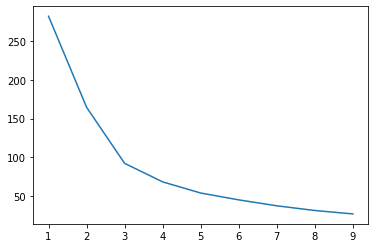

In [23]:
#küme içi kareler toplamı-küme sayısı
from sklearn.cluster import KMeans
list=[]
for i in range(1,10):
    kmeans=KMeans(i)
    kmeans.fit(x_scaled)
    list.append(kmeans.inertia_)
plt.plot(range(1,10),list)
plt.show

In [24]:
kmeans=KMeans(3)
kmeans.fit(x_scaled)
cluster=x.copy()
cluster["küme"]=kmeans.fit_predict(x_scaled)
cluster

,Yıl,Ölü Sayısı,küme
0,1950,150.0,2
1,1953,19.0,2
2,1953,0.0,2
3,1954,8.0,2
4,1954,22.0,2
...,...,...,...
136,2020,152.0,0
137,2020,0.0,1
138,2020,101.0,1
139,2020,72.0,1


<function matplotlib.pyplot.show(close=None, block=None)>

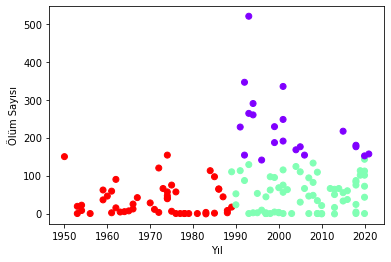

In [26]:
plt.scatter(cluster["Yıl"],cluster["Ölü Sayısı"], c=cluster["küme"],cmap="rainbow")
plt.xlabel("Yıl")
plt.ylabel("Ölüm Sayısı")
plt.show